In [374]:
import networkx as nx 
import cv2
import numpy as np
import matplotlib.pyplot as plt
import sklearn

from skimage.morphology import skeletonize
from skimage.util import img_as_ubyte
from skimage.measure import label
from scipy.ndimage import distance_transform_edt
from sklearn.decomposition import PCA
from collections import defaultdict

In [375]:
import cv2
import numpy as np

img = cv2.imread("ImageData/finalchecker.png", cv2.IMREAD_GRAYSCALE)

# 1) Denoise a bit (preserve edges)
g = cv2.bilateralFilter(img, d=9, sigmaColor=50, sigmaSpace=50)

# 2) Estimate background using a LARGE morphological closing
#    (kernel size is the main knob; should be bigger than stroke thickness)
k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (51, 51))
bg = cv2.morphologyEx(g, cv2.MORPH_CLOSE, k)

# 3) Shading correction: background - image makes dark ink pop bright
fg = cv2.subtract(bg, g)

# Optional: slight blur helps thresholding stability
fg = cv2.GaussianBlur(fg, (0, 0), 1.0)

# 4) Threshold (Otsu usually works *now*)
_, bw = cv2.threshold(fg, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 5) Cleanup (optional)
k3 = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
bw = cv2.morphologyEx(bw, cv2.MORPH_OPEN, k3, iterations=1)   # remove specks
bw = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, k3, iterations=1)  # close small gaps

# Convert to 0/1 (ink = 1)
binary01 = (bw > 0).astype(np.uint8)

cv2.imwrite("ImageData/binary.png", binary01 * 255)


True

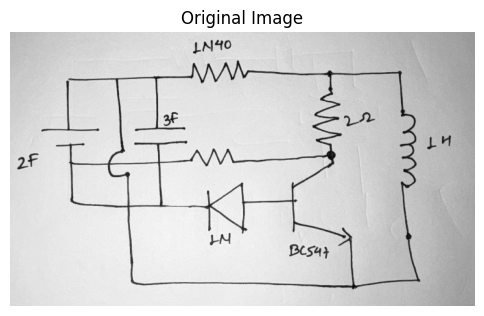

In [376]:
img_path = "/Users/mac/Downloads/LineDetect/ImageData/finalchecker.png"

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Image not found at {img_path}")

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

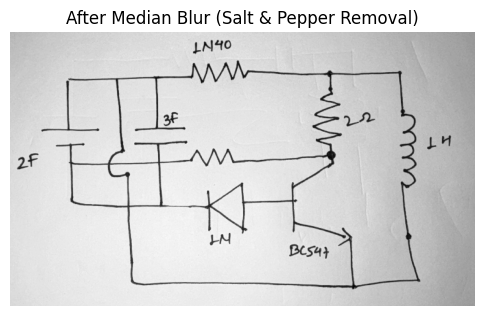

In [377]:
denoised = cv2.medianBlur(img, 1)

plt.figure(figsize=(6,6))
plt.imshow(denoised, cmap="gray")
plt.title("After Median Blur (Salt & Pepper Removal)")
plt.axis("off")
plt.show()


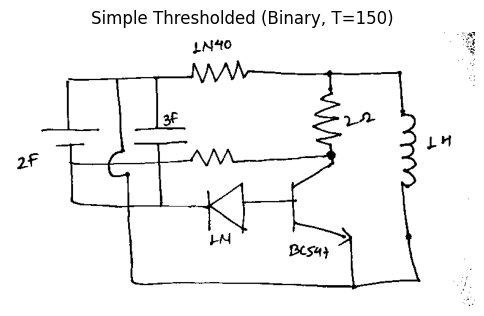

In [378]:
_, simple_bin = cv2.threshold(denoised, 150, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(6,6))
plt.imshow(simple_bin, cmap="gray")
plt.title("Simple Thresholded (Binary, T=150)")
plt.axis("off")
plt.show()

# imsave_path = "/Users/mac/Downloads/LineDetect/ImageData/simple_thresholded.png"
# cv2.imwrite(imsave_path, simple_bin)
# print(f"Simple thresholded image saved at {imsave_path}")


In [379]:
otsu_bin = simple_bin.copy()  # Using the same binary image for skeletonization

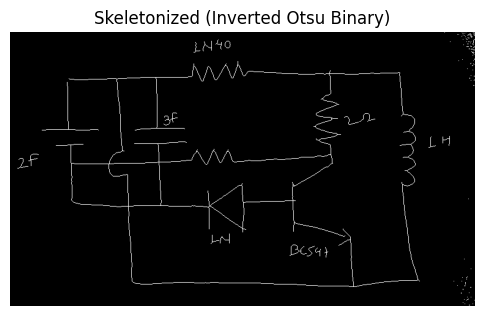

In [380]:
inverted = cv2.bitwise_not(otsu_bin)

# ensure binary is boolean
binary_bool = inverted > 0

# skeletonize
skeleton = skeletonize(binary_bool)

plt.figure(figsize=(6,6))
plt.imshow(skeleton, cmap="gray")
plt.title("Skeletonized (Inverted Otsu Binary)")
plt.axis("off")
plt.show()

In [381]:
label_path = "/Users/mac/Downloads/LineDetect/ImageData/finalchecker.txt"
img = otsu_bin
h, w = img.shape

with open(label_path, "r") as f:
    yolo_lines = [ln.strip() for ln in f.readlines() if ln.strip()]



Found 30 bounding boxes


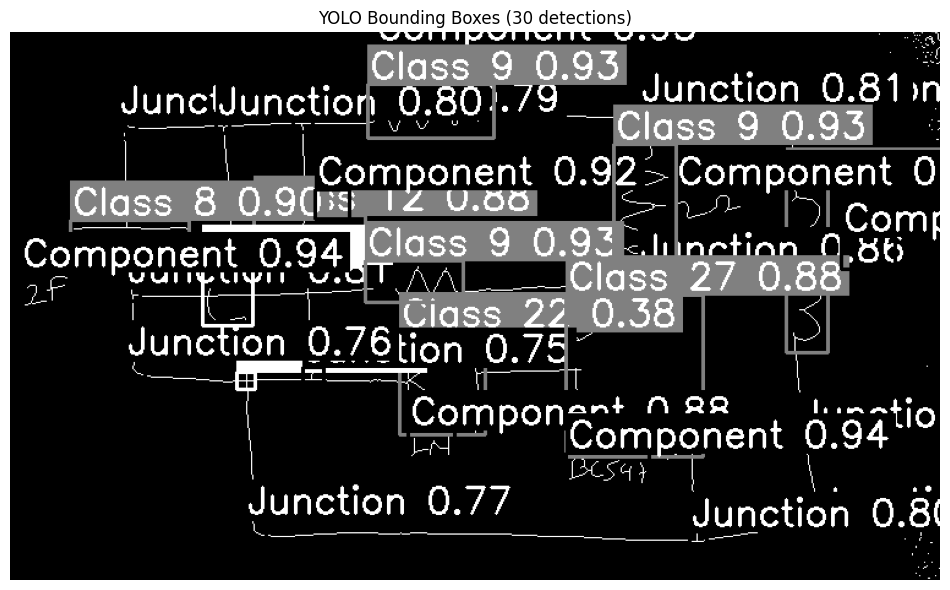


Detections by class:
  Component (class 0): 7
  Junction (class 1): 13
  Line (class 2): 2
  Class 8 (class 8): 1
  Class 9 (class 9): 3
  Class 12 (class 12): 1
  Class 15 (class 15): 1
  Class 22 (class 22): 1
  Class 27 (class 27): 1


In [382]:
# ---------------- Draw YOLO bounding boxes on image ----------------
label_path = "/Users/mac/Downloads/LineDetect/ImageData/finalchecker.txt"

# Read the image and convert to BGR for colored bounding boxes
# vis_img = cv2.cvtColor(skeleton, cv2.COLOR_GRAY2BGR)
vis_img = skeleton.astype(np.uint8) * 255
img_h, img_w = skeleton.shape
# vis_img=img.copy()

# Define colors for different classes (BGR format)
class_colors = {
    0: (0, 0, 255),    # Green for class 0
    1: (0, 0, 255),    # Red for class 1
    2: (255, 0, 0),    # Blue for class 2
    3: (255, 255, 0),  # Cyan for class 3
    4: (255, 0, 255),  # Magenta for class 4
}

class_names = {
    0: "Component",
    1: "Junction",
    2: "Line",
}

# Read YOLO labels and draw boxes
with open(label_path, "r") as f:
    lines = [ln.strip() for ln in f.readlines() if ln.strip()]

print(f"Found {len(lines)} bounding boxes")

for line in lines:
    parts = line.split()
    if len(parts) < 5:
        continue
    
    class_id = int(parts[0])
    x_center = float(parts[1])
    y_center = float(parts[2])
    box_w = float(parts[3])
    box_h = float(parts[4])
    conf = float(parts[5]) if len(parts) > 5 else None
    
    # Convert normalized coords to pixel coords
    x1 = int((x_center - box_w / 2) * img_w)
    y1 = int((y_center - box_h / 2) * img_h)
    x2 = int((x_center + box_w / 2) * img_w)
    y2 = int((y_center + box_h / 2) * img_h)
    
    # Clip to image bounds
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img_w, x2), min(img_h, y2)
    
    # Get color for this class
    color = class_colors.get(class_id, (128, 128, 128))
    
    # Draw rectangle
    cv2.rectangle(vis_img, (x1, y1), (x2, y2), color, 2)
    
    # Draw label
    label = class_names.get(class_id, f"Class {class_id}")
    if conf is not None:
        label = f"{label} {conf:.2f}"
    
    # Label background (larger font size: 1.0 instead of 0.5, thickness: 2 instead of 1)
    font_scale = 1.0
    font_thickness = 2
    (label_w, label_h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, font_thickness)
    cv2.rectangle(vis_img, (x1, y1 - label_h - 10), (x1 + label_w + 5, y1), color, -1)
    cv2.putText(vis_img, label, (x1 + 2, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), font_thickness)

# Display
plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
plt.title(f"YOLO Bounding Boxes ({len(lines)} detections)")
plt.axis("off")
plt.show()

# Count by class
from collections import Counter
class_counts = Counter(int(line.split()[0]) for line in lines if line.split())
print("\nDetections by class:")
for cls_id, count in sorted(class_counts.items()):
    name = class_names.get(cls_id, f"Class {cls_id}")
    print(f"  {name} (class {cls_id}): {count}")

Erased 7 class 0 (Component) regions from skeleton


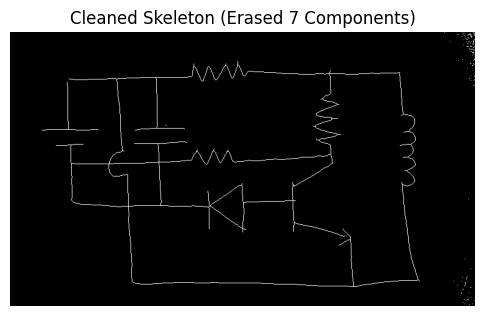

In [383]:
# ---------------- Erase class 0 regions from skeleton ----------------
label_path = "/Users/mac/Downloads/LineDetect/ImageData/finalchecker.txt"

# Create a copy of skeleton to modify
skeleton_cleaned = skeleton.copy()
img_h, img_w = skeleton_cleaned.shape

# Read YOLO labels
with open(label_path, "r") as f:
    lines = [ln.strip() for ln in f.readlines() if ln.strip()]

erased_count = 0

for line in lines:
    parts = line.split()
    if len(parts) < 5:
        continue
    
    class_id = int(parts[0])
    
    # Only erase class 0 (Component) regions
    if class_id == 0:
        x_center = float(parts[1])
        y_center = float(parts[2])
        box_w = float(parts[3])
        box_h = float(parts[4])
        
        # Convert normalized coords to pixel coords
        x1 = int((x_center - box_w / 2) * img_w)
        y1 = int((y_center - box_h / 2) * img_h)
        x2 = int((x_center + box_w / 2) * img_w)
        y2 = int((y_center + box_h / 2) * img_h)
        
        # Clip to image bounds
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(img_w, x2), min(img_h, y2)
        
        # Erase the region (set to False/0)
        skeleton_cleaned[y1:y2, x1:x2] = False
        erased_count += 1

print(f"Erased {erased_count} class 0 (Component) regions from skeleton")

# Display cleaned skeleton
plt.figure(figsize=(6,6))
plt.imshow(skeleton_cleaned, cmap="gray")
plt.title(f"Cleaned Skeleton (Erased {erased_count} Components)")
plt.axis("off")
plt.show()

# Update the skeleton variable for subsequent cells
skeleton = skeleton_cleaned

In [384]:
img = skeleton.astype(np.uint8) * 255

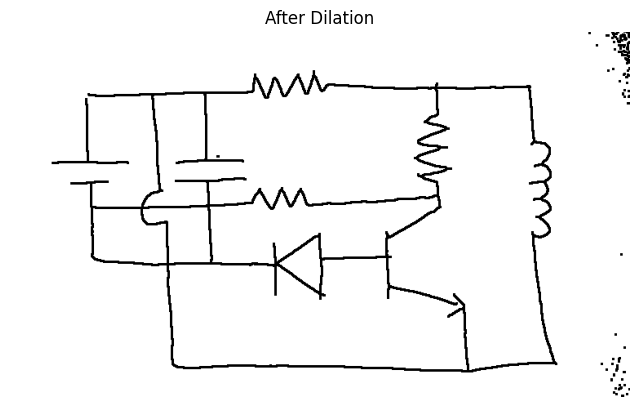

In [385]:
# invert so foreground becomes white for dilation
# inv = cv2.bitwise_not(img)
kernel = np.ones((3, 3), np.uint8)
dilated_inv = cv2.dilate(img, kernel, iterations=1)

# invert back
dilated = cv2.bitwise_not(dilated_inv)

plt.figure(figsize=(8,8))
plt.imshow(dilated, cmap="gray", vmin=0, vmax=255)
plt.title("After Dilation")
plt.axis("off")
plt.show()


Foreground pixels: 15045
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


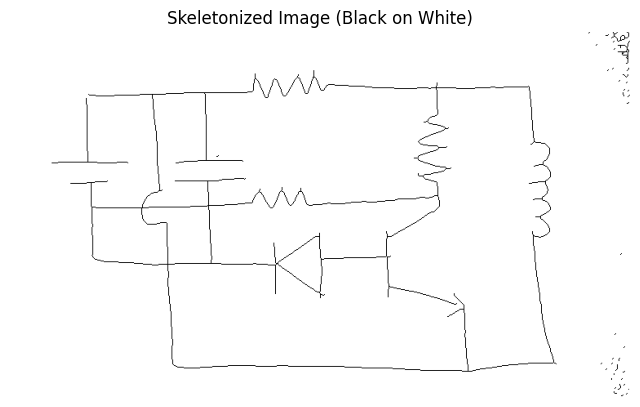

Skeleton image saved to skeleton_black_on_white.png


In [386]:
from skimage.io import imsave

# Foreground = black pixels
binary = (dilated < 128).astype(np.uint8)   # 1 where black line exists

print("Foreground pixels:", np.sum(binary))

skel = skeletonize(binary).astype(np.uint8)
skel_u8 = img_as_ubyte(skel)

# Convert to black skeleton on white background for display
skel_black_on_white = np.ones_like(dilated) * 255
skel_black_on_white[skel_u8 > 0] = 0
print(skel)

plt.figure(figsize=(8,8))
plt.imshow(skel_black_on_white, cmap="gray", vmin=0, vmax=255)
plt.title("Skeletonized Image (Black on White)")
plt.axis("off")
plt.show()


output_path = "skeleton_black_on_white.png"
imsave(output_path, skel_black_on_white.astype(np.uint8))

print(f"Skeleton image saved to {output_path}")

In [387]:
img = cv2.imread("skeleton_black_on_white.png", cv2.IMREAD_GRAYSCALE)

print(img.shape, img.dtype)

(448, 760) uint8


{'id': 22, 'conf': 0.379806, 'bbox_xyxy': (318, 246, 388, 330), 'endpoints': [(318, 286), (388, 278)], 'method': 'all_border_hits_cleaned'}
{'id': 1, 'conf': 0.520798, 'bbox_xyxy': (644, 327, 658, 342), 'endpoint_xy': (651, 334), 'method': 'cls1_center_snap'}
{'id': 2, 'conf': 0.598977, 'bbox_xyxy': (186, 278, 201, 292), 'endpoint_xy': (194, 285), 'method': 'cls1_center_snap'}
{'id': 1, 'conf': 0.689856, 'bbox_xyxy': (88, 72, 103, 88), 'endpoint_xy': (97, 78), 'method': 'cls1_center_snap'}
{'id': 1, 'conf': 0.752785, 'bbox_xyxy': (239, 275, 256, 291), 'endpoint_xy': (248, 284), 'method': 'cls1_center_snap'}
{'id': 1, 'conf': 0.763337, 'bbox_xyxy': (94, 268, 110, 285), 'endpoint_xy': (101, 276), 'method': 'cls1_center_snap'}
{'id': 1, 'conf': 0.767561, 'bbox_xyxy': (192, 399, 209, 417), 'endpoint_xy': (200, 408), 'method': 'cls1_center_snap'}
{'id': 1, 'conf': 0.781066, 'bbox_xyxy': (661, 399, 674, 411), 'endpoint_xy': (668, 406), 'method': 'cls1_center_snap'}
{'id': 1, 'conf': 0.792839

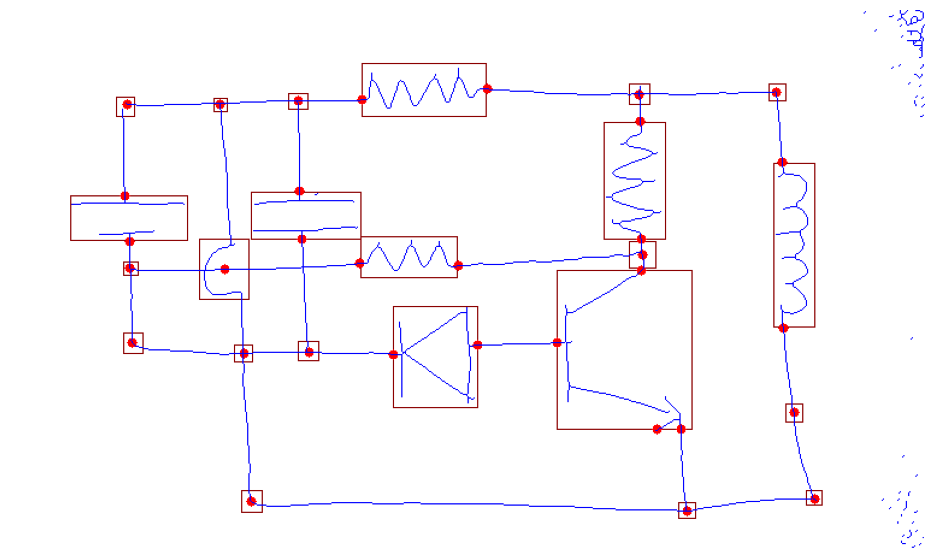

In [388]:
import numpy as np
import cv2
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt

# ---------------- IO helpers ----------------
def load_yolo_detections(txt_path):
    """
    Each line: cls xc yc w h conf (normalized except cls/conf)
    """
    dets = []
    try:
        with open(txt_path, "r") as f:
            for line in f:
                if not line.strip():
                    continue
                parts = line.strip().split()
                cls = int(parts[0])
                xc, yc, w, h = map(float, parts[1:5])
                conf = float(parts[5]) if len(parts) > 5 else None
                dets.append((cls, xc, yc, w, h, conf))
    except FileNotFoundError:
        print(f"Warning: YOLO file not found at {txt_path}")
    return dets

def yolo_to_xyxy(xc, yc, w, h, W, H):
    x1 = int(round((xc - w/2) * W))
    y1 = int(round((yc - h/2) * H))
    x2 = int(round((xc + w/2) * W))
    y2 = int(round((yc + h/2) * H))
    # Clip to image boundaries
    x1, y1 = max(0, min(W-1, x1)), max(0, min(H-1, y1))
    x2, y2 = max(0, min(W-1, x2)), max(0, min(H-1, y2))
    # Ensure x1 < x2 and y1 < y2
    if x2 < x1: x1, x2 = x2, x1
    if y2 < y1: y1, y2 = y2, y1
    return x1, y1, x2, y2

# ---------------- Skeleton / Geometry Helpers ----------------
def get_all_border_intersections(skel, inter_xy, merge_dist=8.0):
    """
    Returns unique skeleton hits on the border.
    Groups pixels within merge_dist to prevent 'staircase' repeats.
    """
    if len(inter_xy) == 0:
        return [], "no_border_hits"
    
    # 1. Get unique integer coordinate tuples
    raw_pts = sorted(list(set(tuple(map(int, p)) for p in inter_xy)))
    
    # 2. Grouping logic using a simple distance-based cluster
    merged = []
    while raw_pts:
        curr = raw_pts.pop(0)
        found_group = False
        
        for i, m in enumerate(merged):
            # Calculate Euclidean distance
            dist = np.sqrt((curr[0] - m[0])**2 + (curr[1] - m[1])**2)
            
            if dist <= merge_dist:
                # Update merged point to the average of the cluster
                new_x = int(round((curr[0] + m[0]) / 2))
                new_y = int(round((curr[1] + m[1]) / 2))
                merged[i] = (new_x, new_y)
                found_group = True
                break
        
        if not found_group:
            merged.append(curr)
            
    return merged, "all_border_hits_cleaned"

def skeleton_intersections_with_bbox_border(skel, x1, y1, x2, y2, tol=1):
    """
    Isolates skeleton pixels lying on the border of the bounding box.
    """
    H, W = skel.shape
    xx1, yy1 = max(0, x1 - tol), max(0, y1 - tol)
    xx2, yy2 = min(W-1, x2 + tol), min(H-1, y2 + tol)

    band = np.zeros_like(skel, dtype=bool)
    band[yy1:yy2+1, xx1:xx2+1] = True

    # Carve out the interior to keep only the boundary area
    if (x2 - x1) > 2*tol and (y2 - y1) > 2*tol:
        band[y1+tol:y2-tol+1, x1+tol:x2-tol+1] = False

    ys, xs = np.where((skel > 0) & band)
    if len(xs) == 0:
        return np.empty((0,2), dtype=int)
    return np.stack([xs, ys], axis=1)

# ---------------- Class 1 & 2 Helpers ----------------
def nearest_skeleton_point_with_dist(skel, anchor_xy, search_xyxy):
    x1, y1, x2, y2 = search_xyxy
    roi = skel[y1:y2+1, x1:x2+1]
    ys, xs = np.where(roi > 0)
    if len(xs) == 0:
        return None, None

    pts = np.stack([x1+xs, y1+ys], axis=1)
    ax, ay = anchor_xy
    d2 = (pts[:,0]-ax)**2 + (pts[:,1]-ay)**2
    i = int(np.argmin(d2))
    return tuple(map(int, pts[i])), float(d2[i])

def endpoint_for_class1_single(skel, x1, y1, x2, y2, margin=8):
    H, W = skel.shape
    xc, yc = int(round((x1 + x2) / 2)), int(round((y1 + y2) / 2))
    sx1, sy1 = max(0, x1 - margin), max(0, y1 - margin)
    sx2, sy2 = min(W - 1, x2 + margin), min(H - 1, y2 + margin)

    p, _ = nearest_skeleton_point_with_dist(skel, (xc, yc), (sx1, sy1, sx2, sy2))
    return p, "cls1_center_snap" if p else "cls1_not_found"

# ---------------- Main Pipeline ----------------
def detect_endpoints(image_path, txt_path, thresh=128, border_tol=1, cls1_margin=8):
    # Load and Pre-process
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if gray is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    H, W = gray.shape

    # Binarize and Skeletonize
    binary = (gray < thresh).astype(np.uint8)
    skel = skeletonize(binary.astype(bool)).astype(np.uint8)

    dets = load_yolo_detections(txt_path)
    results = []

    for cls, xc, yc, w, h, conf in dets:
        if cls == 0: continue # Skip class 0
        
        x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, w, h, W, H)

        if cls == 1 or cls == 2:
            ep, method = endpoint_for_class1_single(skel, x1, y1, x2, y2, margin=cls1_margin)
            results.append({
                "id": cls, "conf": conf, "bbox_xyxy": (x1, y1, x2, y2),
                "endpoint_xy": ep, "method": method
            })
        else:
            inter = skeleton_intersections_with_bbox_border(skel, x1, y1, x2, y2, tol=border_tol)
            if len(inter) == 0:
                roi = skel[y1:y2+1, x1:x2+1]
                ys, xs = np.where(roi > 0)
                pts = [tuple(map(int, p)) for p in np.stack([x1+xs, y1+ys], axis=1)]
                method = "fallback_internal"
            else:
                pts, method = get_all_border_intersections(skel, inter)

            results.append({
                "id": cls, "conf": conf, "bbox_xyxy": (x1, y1, x2, y2),
                "endpoints": pts, "method": method
            })

    return results, skel

# ---------------- Visualization ----------------
def visualize_results(image_path, results, skel=None, draw_skeleton=False, output_path=None):
    # Load original image
    gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    for r in results:
        x1, y1, x2, y2 = r["bbox_xyxy"]
        # Draw bounding box (Dark Red)
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 0, 139), 1)

        # Draw single endpoints (Class 1 & 2)
        if "endpoint_xy" in r and r["endpoint_xy"]:
            cv2.circle(vis, r["endpoint_xy"], 4, (0, 0, 255), -1)
        
        # Draw multiple endpoints from list (Other classes)
        if "endpoints" in r:
            for p in r["endpoints"]:
                cv2.circle(vis, p, 4, (0, 0, 255), -1)

    # Overlay the skeleton if requested
    if draw_skeleton and skel is not None:
        vis[skel > 0] = (255, 0, 0) # Blue color for skeleton

    # Convert BGR to RGB for Matplotlib
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12, 7))
    plt.imshow(vis_rgb)
    plt.axis("off")
    
    # --- SAVE LOGIC ---
    if output_path:
        plt.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
        print(f"Visualization saved to: {output_path}")
    
    plt.show()
# ---------------- Execution ----------------
image_path = "/Users/mac/Downloads/LineDetect/skeleton_black_on_white.png"
txt_path = "/Users/mac/Downloads/LineDetect/ImageData/finalchecker.txt"
output_png = "/Users/mac/Downloads/LineDetect/output_visualization.png"

results, skel_img = detect_endpoints(image_path, txt_path)

for res in results:
    print(res)

visualize_results(image_path, results, skel=skel_img, draw_skeleton=True, output_path=output_png)

In [389]:
import numpy as np

def extract_all_endpoints(results, global_merge_dist=5):
    """
    Extract all unique endpoints from results.
    Consolidates points that are physically close to each other across different boxes.
    """
    all_pts = []
    for r in results:
        # 1. Handle Class 1 & 2
        if "endpoint_xy" in r and r["endpoint_xy"] is not None:
            all_pts.append(tuple(map(int, r["endpoint_xy"])))
        
        # 2. Handle Other Classes (List of points)
        if "endpoints" in r and r["endpoints"]:
            for ep in r["endpoints"]:
                if ep is not None:
                    all_pts.append(tuple(map(int, ep)))
                    
        # 3. Legacy support
        for legacy_key in ["endpoint1_xy", "endpoint2_xy"]:
            if legacy_key in r and r[legacy_key] is not None:
                all_pts.append(tuple(map(int, r[legacy_key])))

    if not all_pts:
        return []

    # --- Robust De-duplication (Proximity based) ---
    unique = []
    for pt in all_pts:
        if not unique:
            unique.append(pt)
            continue
        
        # Check if this point is close to any point already added
        pt_arr = np.array(pt)
        unique_arr = np.array(unique)
        distances = np.linalg.norm(unique_arr - pt_arr, axis=1)
        
        if np.min(distances) > global_merge_dist:
            unique.append(pt)
            
    return unique

In [ ]:

# def visualize_results_and_save(
#     image_path,
#     results,
#     output_path,
#     skel=None,
#     draw_skeleton=False
# ):
#     import cv2
#     import numpy as np

#     gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
#     vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

#     for r in results:
#         x1, y1, x2, y2 = r["bbox_xyxy"]
#         cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 0, 139), 1)

#         if "endpoint_xy" in r:
#             p = r["endpoint_xy"]
#             if p is not None:
#                 cv2.circle(vis, p, 4, (0, 0, 255), -1)
#         else:
#             for k in ["endpoint1_xy", "endpoint2_xy"]:
#                 p = r.get(k)
#                 if p is not None:
#                     cv2.circle(vis, p, 4, (0, 0, 255), -1)

#     if draw_skeleton and skel is not None:
#         ys, xs = np.where(skel > 0)
#         vis[ys, xs] = (255, 0, 0)

#     # ---- SAVE AS PNG ----
#     cv2.imwrite(output_path, vis)
#     print(f"Saved visualization to: {output_path}")

# output_png = "/Users/mac/Downloads/LineDetect/output_visualization.png"

# visualize_results_and_save(
#     image_path=image_path,
#     results=results,
#     output_path=output_png,
#     draw_skeleton=True,
#     skel=skel
# )


In [391]:
results

[{'id': 22,
  'conf': 0.379806,
  'bbox_xyxy': (318, 246, 388, 330),
  'endpoints': [(318, 286), (388, 278)],
  'method': 'all_border_hits_cleaned'},
 {'id': 1,
  'conf': 0.520798,
  'bbox_xyxy': (644, 327, 658, 342),
  'endpoint_xy': (651, 334),
  'method': 'cls1_center_snap'},
 {'id': 2,
  'conf': 0.598977,
  'bbox_xyxy': (186, 278, 201, 292),
  'endpoint_xy': (194, 285),
  'method': 'cls1_center_snap'},
 {'id': 1,
  'conf': 0.689856,
  'bbox_xyxy': (88, 72, 103, 88),
  'endpoint_xy': (97, 78),
  'method': 'cls1_center_snap'},
 {'id': 1,
  'conf': 0.752785,
  'bbox_xyxy': (239, 275, 256, 291),
  'endpoint_xy': (248, 284),
  'method': 'cls1_center_snap'},
 {'id': 1,
  'conf': 0.763337,
  'bbox_xyxy': (94, 268, 110, 285),
  'endpoint_xy': (101, 276),
  'method': 'cls1_center_snap'},
 {'id': 1,
  'conf': 0.767561,
  'bbox_xyxy': (192, 399, 209, 417),
  'endpoint_xy': (200, 408),
  'method': 'cls1_center_snap'},
 {'id': 1,
  'conf': 0.781066,
  'bbox_xyxy': (661, 399, 674, 411),
  'endpo

In [392]:
arrayendpoints2 = extract_all_endpoints(results)
print("All extracted endpoints:", arrayendpoints2)

All extracted endpoints: [(318, 286), (388, 278), (651, 334), (194, 285), (97, 78), (248, 284), (101, 276), (200, 408), (668, 406), (239, 75), (636, 68), (174, 78), (562, 416), (522, 70), (99, 214), (641, 126), (642, 264), (525, 203), (454, 276), (524, 216), (537, 348), (557, 348), (240, 150), (242, 190), (178, 215), (95, 154), (99, 192), (290, 210), (372, 212), (523, 92), (524, 190), (292, 74), (396, 65)]


In [393]:
endpoints_only = [
    (r["endpoint1_xy"], r["endpoint2_xy"])
    for r in results
    if "endpoint1_xy" in r and "endpoint2_xy" in r
]
print("Extracted endpoint pairs for cls!=1:", endpoints_only)

Extracted endpoint pairs for cls!=1: []


In [394]:
from collections import deque
import numpy as np

# ---------------- Helpers ----------------

def get_neighbors8(y, x, H, W):
    """Return list of valid 8-connected neighbor coordinates (y, x)."""
    neighbors = []
    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:
            if dy == 0 and dx == 0:
                continue
            ny, nx = y + dy, x + dx
            if 0 <= ny < H and 0 <= nx < W:
                neighbors.append((ny, nx))
    return neighbors

def disk_mask(radius):
    """
    Return a list of (dy, dx) offsets for a filled disk of given radius.
    Includes center (0,0).
    """
    offsets = []
    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            if dy * dy + dx * dx <= radius * radius:
                offsets.append((dy, dx))
    return offsets

def build_node_id_map(skel, nodes, radius=20):
    """
    Build a node_id_map image where each pixel is:
      - node index i if within radius of node i
      - -1 otherwise
    
    Args:
        skel: (H, W) skeleton array
        nodes: list of (x, y) node coordinates
        radius: disk radius around each node
    
    Returns:
        node_id_map: (H, W) int array, -1 for non-node pixels
    """
    H, W = skel.shape
    node_id_map = np.full((H, W), -1, dtype=np.int32)
    
    disk = disk_mask(radius)
    
    for i, (nx, ny) in enumerate(nodes):
        for dy, dx in disk:
            py, px = ny + dy, nx + dx
            if 0 <= py < H and 0 <= px < W:
                node_id_map[py, px] = i
    
    return node_id_map

def bfs_neighbors_for_node(node_idx, nodes, skel, node_id_map, radius=20):
    """
    BFS from node node_idx along skeleton pixels.
    Stop each branch when hitting another node.
    
    Returns:
        set of neighbor node indices
    """
    H, W = skel.shape
    nx, ny = nodes[node_idx]
    
    neighbors_found = set()
    
    # Visited array for this BFS (pixel-level)
    visited = np.zeros((H, W), dtype=bool)
    
    # Mark the starting node's disk region as visited (to avoid self-hits)
    disk = disk_mask(radius)
    for dy, dx in disk:
        py, px = ny + dy, nx + dx
        if 0 <= py < H and 0 <= px < W:
            visited[py, px] = True
    
    # Initialize queue with skeleton pixels at the edge of the node's disk
    # These are pixels adjacent to the disk that are on the skeleton
    queue = deque()
    
    for dy, dx in disk:
        py, px = ny + dy, nx + dx
        if 0 <= py < H and 0 <= px < W:
            # Check 8-neighbors of this disk pixel
            for npy, npx in get_neighbors8(py, px, H, W):
                if not visited[npy, npx] and skel[npy, npx] > 0:
                    visited[npy, npx] = True
                    queue.append((npy, npx))
    
    # BFS
    while queue:
        cy, cx = queue.popleft()
        
        # Check if this pixel is part of another node
        other_node = node_id_map[cy, cx]
        if other_node != -1 and other_node != node_idx:
            # Found a neighbor node - record it and stop this branch
            neighbors_found.add(other_node)
            continue  # Do NOT enqueue neighbors from this pixel
        
        # Continue BFS: enqueue skeleton neighbors
        for npy, npx in get_neighbors8(cy, cx, H, W):
            if not visited[npy, npx] and skel[npy, npx] > 0:
                visited[npy, npx] = True
                queue.append((npy, npx))
    
    return neighbors_found

def build_adjacency(skel, nodes, radius=20):
    """
    Build adjacency dict from skeleton and node list.
    
    Args:
        skel: (H, W) skeleton array
        nodes: list of (x, y) node coordinates
        radius: disk radius for node detection
    
    Returns:
        adjacency: dict[int, set[int]] - undirected graph adjacency
    """
    print(f"Building adjacency for {len(nodes)} nodes with radius={radius}...")
    
    # Build node_id_map
    node_id_map = build_node_id_map(skel, nodes, radius)
    
    # Initialize adjacency
    adjacency = {i: set() for i in range(len(nodes))}
    
    # BFS from each node
    for i in range(len(nodes)):
        neighbors = bfs_neighbors_for_node(i, nodes, skel, node_id_map, radius)
        for j in neighbors:
            adjacency[i].add(j)
            adjacency[j].add(i)  # Undirected
    
    return adjacency

# ---------------- Build adjacency ----------------
adjacency = build_adjacency(skel, arrayendpoints2, radius=20)

# ---------------- Print adjacency ----------------
print("\n=== Node Adjacency ===")
for i, neighbors in adjacency.items():
    node_coord = arrayendpoints2[i]
    neighbor_strs = [f"{j} {arrayendpoints2[j]}" for j in sorted(neighbors)]
    print(f"Node {i} {node_coord}: -> {neighbor_strs}")

print(f"\n=== Summary ===")
total_edges = sum(len(n) for n in adjacency.values()) // 2
print(f"Total nodes: {len(adjacency)}")
print(f"Total edges: {total_edges}")

# Check connectivity
from collections import deque as dq
def count_components(adj):
    visited = set()
    components = 0
    for start in adj:
        if start not in visited:
            components += 1
            q = dq([start])
            while q:
                node = q.popleft()
                if node in visited:
                    continue
                visited.add(node)
                for neighbor in adj[node]:
                    if neighbor not in visited:
                        q.append(neighbor)
    return components

num_components = count_components(adjacency)
print(f"Connected components: {num_components}")

Building adjacency for 33 nodes with radius=20...

=== Node Adjacency ===
Node 0 (318, 286): -> ['1 (388, 278)', '5 (248, 284)']
Node 1 (388, 278): -> ['0 (318, 286)', '18 (454, 276)']
Node 2 (651, 334): -> ['8 (668, 406)', '16 (642, 264)']
Node 3 (194, 285): -> ['5 (248, 284)', '6 (101, 276)', '7 (200, 408)', '24 (178, 215)']
Node 4 (97, 78): -> ['11 (174, 78)', '25 (95, 154)']
Node 5 (248, 284): -> ['0 (318, 286)', '3 (194, 285)', '23 (242, 190)', '24 (178, 215)', '27 (290, 210)']
Node 6 (101, 276): -> ['3 (194, 285)', '14 (99, 214)']
Node 7 (200, 408): -> ['3 (194, 285)', '12 (562, 416)']
Node 8 (668, 406): -> ['2 (651, 334)', '12 (562, 416)']
Node 9 (239, 75): -> ['11 (174, 78)', '22 (240, 150)', '31 (292, 74)']
Node 10 (636, 68): -> ['13 (522, 70)', '15 (641, 126)']
Node 11 (174, 78): -> ['4 (97, 78)', '9 (239, 75)', '24 (178, 215)']
Node 12 (562, 416): -> ['7 (200, 408)', '8 (668, 406)', '21 (557, 348)']
Node 13 (522, 70): -> ['10 (636, 68)', '29 (523, 92)', '32 (396, 65)']
Node 

In [395]:
import numpy as np

def find_node_index(target_coord, all_nodes, dist_threshold=2):
    """
    Finds index with a small distance tolerance to handle 
    pixel-level shifts.
    """
    target = np.array(target_coord)
    nodes = np.array(all_nodes)
    
    # Calculate Euclidean distances to all nodes
    distances = np.linalg.norm(nodes - target, axis=1)
    min_idx = np.argmin(distances)
    
    if distances[min_idx] <= dist_threshold:
        return int(min_idx)
    return -1

# ... in your loop ...

for (p1, p2) in endpoints_only:
    idx1 = find_node_index(p1, arrayendpoints2)
    idx2 = find_node_index(p2, arrayendpoints2)

    if idx1 == -1 or idx2 == -1:
        # Better logging to see why it failed
        print(f"Skipping: {p1 if idx1==-1 else p2} not near any node.")
        continue

    # Use .discard() if you can convert your adjacency lists to sets
    # This prevents errors if the pair (p1, p2) appears twice in endpoints_only
    if idx2 in adjacency[idx1]:
        # If adjacency[idx1] is a list:
        adjacency[idx1] = [n for n in adjacency[idx1] if n != idx2]
        # If adjacency[idx2] is a list:
        adjacency[idx2] = [n for n in adjacency[idx2] if n != idx1]
        print(f"Removed: {idx1} <-> {idx2}")

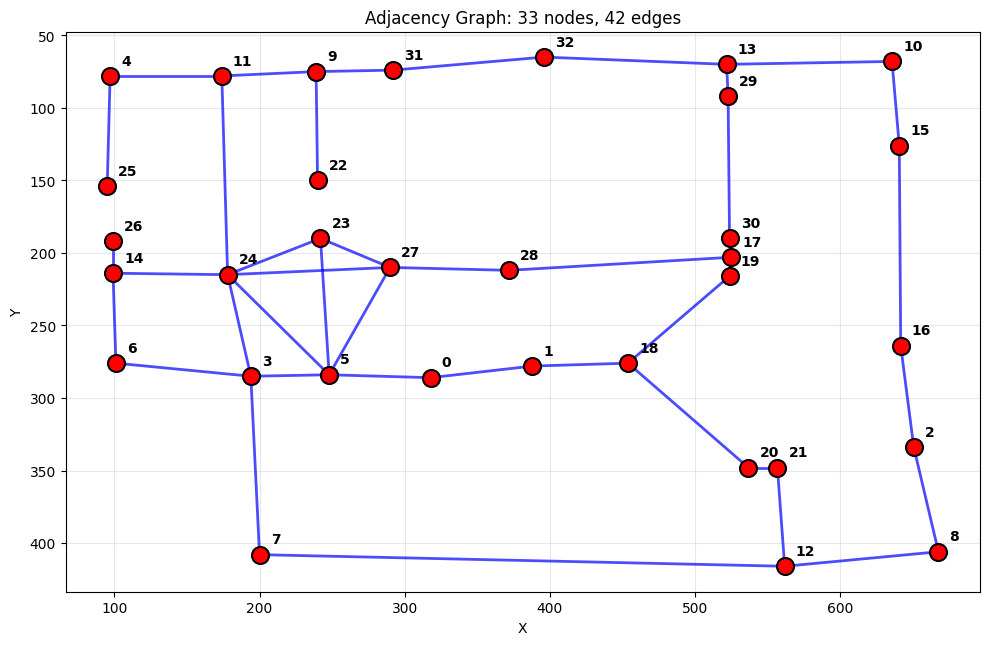

In [396]:
# ---------------- Visualize adjacency graph with raw lines ----------------
import matplotlib.pyplot as plt

def plot_adjacency_graph(nodes, adjacency, figsize=(10, 10)):
    """
    Plot the adjacency graph as raw lines on a blank canvas.
    
    Args:
        nodes: list of (x, y) node coordinates
        adjacency: dict[int, set[int]] adjacency
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Draw edges
    drawn_edges = set()
    for i, neighbors in adjacency.items():
        x1, y1 = nodes[i]
        for j in neighbors:
            # Avoid drawing same edge twice
            edge = tuple(sorted([i, j]))
            if edge in drawn_edges:
                continue
            drawn_edges.add(edge)
            
            x2, y2 = nodes[j]
            ax.plot([x1, x2], [y1, y2], 'b-', linewidth=2, alpha=0.7)
    
    # Draw nodes
    xs = [n[0] for n in nodes]
    ys = [n[1] for n in nodes]
    ax.scatter(xs, ys, s=150, c='red', zorder=5, edgecolors='black', linewidths=1.5)
    
    # Label nodes
    for i, (x, y) in enumerate(nodes):
        ax.annotate(str(i), (x, y), textcoords="offset points", 
                    xytext=(8, 8), fontsize=10, fontweight='bold')
    
    # Invert y-axis to match image coordinates (origin top-left)
    ax.invert_yaxis()
    
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Adjacency Graph: {len(nodes)} nodes, {len(drawn_edges)} edges')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot the adjacency graph
plot_adjacency_graph(arrayendpoints2, adjacency)

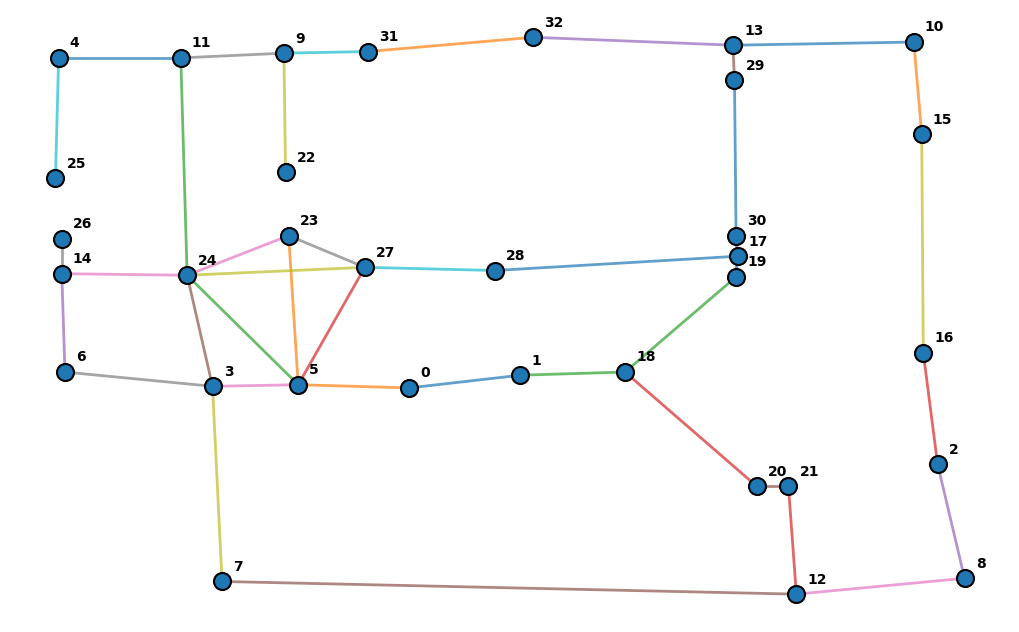

In [397]:
# ---------------- Visualize adjacency graph with raw lines ----------------
import matplotlib.pyplot as plt

def plot_adjacency_graph(nodes, adjacency, figsize=(10, 10)):
    """
    Plot the adjacency graph as raw lines on a plain white canvas.
    
    Args:
        nodes: list of (x, y) node coordinates
        adjacency: dict[int, set[int]] adjacency
    """
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')
    ax.set_facecolor('white')
    
    # Draw edges
    drawn_edges = set()
    for i, neighbors in adjacency.items():
        x1, y1 = nodes[i]
        for j in neighbors:
            edge = tuple(sorted([i, j]))
            if edge in drawn_edges:
                continue
            drawn_edges.add(edge)
            
            x2, y2 = nodes[j]
            ax.plot([x1, x2], [y1, y2], linewidth=2, alpha=0.7)
    
    # Draw nodes
    xs = [n[0] for n in nodes]
    ys = [n[1] for n in nodes]
    ax.scatter(xs, ys, s=150, zorder=5, edgecolors='black', linewidths=1.5)
    
    # Label nodes
    for i, (x, y) in enumerate(nodes):
        ax.annotate(
            str(i),
            (x, y),
            textcoords="offset points",
            xytext=(8, 8),
            fontsize=10,
            fontweight='bold'
        )
    
    # Invert y-axis to match image coordinates (origin top-left)
    ax.invert_yaxis()
    
    ax.set_aspect('equal')
    
    # Remove axes, grid, and frame
    ax.axis('off')
    ax.grid(False)
    
    plt.tight_layout(pad=0)
    plt.show()

# Plot the adjacency graph
plot_adjacency_graph(arrayendpoints2, adjacency)


In [398]:
import matplotlib.pyplot as plt

def plot_adjacency_graph(nodes, adjacency, figsize=(10, 10), out_svg=None):
    """
    Plot the adjacency graph as raw lines on a blank canvas.

    Args:
        nodes: list of (x, y) node coordinates
        adjacency: dict[int, set[int]] adjacency
        out_svg: if provided (str path), saves the plot as an SVG to this path
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Draw edges
    drawn_edges = set()
    for i, neighbors in adjacency.items():
        x1, y1 = nodes[i]
        for j in neighbors:
            edge = tuple(sorted((i, j)))
            if edge in drawn_edges:
                continue
            drawn_edges.add(edge)

            x2, y2 = nodes[j]
            ax.plot([x1, x2], [y1, y2], 'b-', linewidth=2, alpha=0.7)

    # Draw nodes
    xs = [n[0] for n in nodes]
    ys = [n[1] for n in nodes]
    ax.scatter(xs, ys, s=150, c='red', zorder=5, edgecolors='black', linewidths=1.5)

    # Label nodes
    for i, (x, y) in enumerate(nodes):
        ax.annotate(str(i), (x, y), textcoords="offset points",
                    xytext=(8, 8), fontsize=10, fontweight='bold')

    # Invert y-axis to match image coordinates (origin top-left)
    ax.invert_yaxis()

    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Adjacency Graph: {len(nodes)} nodes, {len(drawn_edges)} edges')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if out_svg:
        fig.savefig(out_svg, format="svg", bbox_inches="tight")
        plt.close(fig)  # prevents duplicate display in notebooks
    else:
        plt.show()

# Save as SVG
plot_adjacency_graph(arrayendpoints2, adjacency, out_svg="adjacency_graph.svg")


In [399]:
import matplotlib.pyplot as plt

def plot_adjacency_graph(nodes, adjacency, figsize=(10, 10), out_png=None):
    fig, ax = plt.subplots(figsize=figsize)

    # Draw edges
    drawn_edges = set()
    for i, neighbors in adjacency.items():
        x1, y1 = nodes[i]
        for j in neighbors:
            edge = tuple(sorted((i, j)))
            if edge in drawn_edges:
                continue
            drawn_edges.add(edge)

            x2, y2 = nodes[j]
            ax.plot([x1, x2], [y1, y2], 'b-', linewidth=2, alpha=0.7)

    # Draw nodes
    xs = [n[0] for n in nodes]
    ys = [n[1] for n in nodes]
    ax.scatter(xs, ys, s=150, c='red', zorder=5,
               edgecolors='black', linewidths=1.5)

    # Label nodes
    for i, (x, y) in enumerate(nodes):
        ax.annotate(str(i), (x, y),
                    textcoords="offset points",
                    xytext=(8, 8),
                    fontsize=10,
                    fontweight='bold')

    ax.invert_yaxis()
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Adjacency Graph: {len(nodes)} nodes, {len(drawn_edges)} edges')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if out_png:
        fig.savefig(out_png, dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()

# Save as PNG
plot_adjacency_graph(arrayendpoints2, adjacency, out_png="adjacency_graph.png")


In [400]:
adjacency

{0: {np.int32(1), np.int32(5)},
 1: {0, np.int32(18)},
 2: {np.int32(8), np.int32(16)},
 3: {np.int32(5), np.int32(6), np.int32(7), np.int32(24)},
 4: {np.int32(11), np.int32(25)},
 5: {0, 3, np.int32(23), np.int32(24), np.int32(27)},
 6: {3, np.int32(14)},
 7: {3, np.int32(12)},
 8: {2, np.int32(12)},
 9: {np.int32(11), np.int32(22), np.int32(31)},
 10: {np.int32(13), np.int32(15)},
 11: {4, 9, np.int32(24)},
 12: {7, 8, np.int32(21)},
 13: {10, np.int32(29), np.int32(32)},
 14: {6, np.int32(24), np.int32(26)},
 15: {10, np.int32(16)},
 16: {2, 15},
 17: {np.int32(19), np.int32(28), np.int32(30)},
 18: {1, np.int32(19), np.int32(20)},
 19: {17, 18, np.int32(30)},
 20: {18, np.int32(21)},
 21: {12, 20},
 22: {9},
 23: {5, np.int32(24), np.int32(27)},
 24: {3, 5, 11, 14, 23, np.int32(27)},
 25: {4},
 26: {14},
 27: {5, 23, 24, np.int32(28)},
 28: {17, 27},
 29: {13, np.int32(30)},
 30: {17, 19, 29},
 31: {9, np.int32(32)},
 32: {13, 31}}

Found 30 bounding boxes


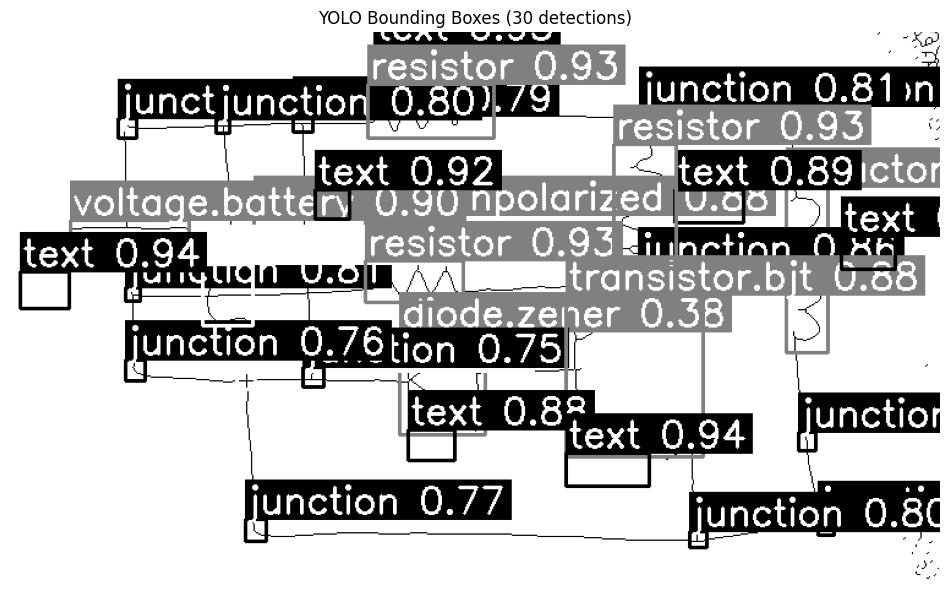


Detections by class:
  text (class 0): 7
  junction (class 1): 13
  crossover (class 2): 2
  voltage.battery (class 8): 1
  resistor (class 9): 3
  capacitor.unpolarized (class 12): 1
  inductor (class 15): 1
  diode.zener (class 22): 1
  transistor.bjt (class 27): 1


In [401]:
# ---------------- Draw YOLO bounding boxes on image ----------------
label_path = "/Users/mac/Downloads/LineDetect/ImageData/finalchecker.txt"

# Read the image and convert to BGR for colored bounding boxes
# vis_img = cv2.cvtColor(skeleton, cv2.COLOR_GRAY2BGR)
vis_img = skeleton.astype(np.uint8) * 255
img_h, img_w = skeleton.shape
vis_img=img.copy()


component_names = [
    "text",
    "junction",
    "crossover",
    "terminal",
    "gnd",
    "vss",
    "voltage.dc",
    "voltage.ac",
    "voltage.battery",
    "resistor",
    "resistor.adjustable",
    "resistor.photo",
    "capacitor.unpolarized",
    "capacitor.polarized",
    "capacitor.adjustable",
    "inductor",
    "inductor.ferrite",
    "inductor.coupled",
    "transformer",
    "diode",
    "diode.light_emitting",
    "diode.thyrector",
    "diode.zener",
    "diac",
    "triac",
    "thyristor",
    "varistor",
    "transistor.bjt",
    "transistor.fet",
    "transistor.photo",
    "operational_amplifier",
    "operational_amplifier.schmitt_trigger",
    "optocoupler",
    "integrated_circuit",
    "integrated_circuit.ne555",
    "integrated_circuit.voltage_regulator",
    "xor",
    "and",
    "or",
    "not",
    "nand",
    "nor",
    "probe",
    "probe.current",
    "probe.voltage",
    "switch",
    "relay",
    "socket",
    "fuse",
    "speaker",
    "motor",
    "lamp",
    "microphone",
    "antenna",
    "crystal",
    "magnetic",
    "mechanical",
    "block",
    "explanatory",
    "unknown"
]


# Define colors for different classes (BGR format)
class_colors = {
    0: (0, 0, 255),    # Green for class 0
    1: (0, 0, 255),    # Red for class 1
    2: (255, 0, 0),    # Blue for class 2
    3: (255, 255, 0),  # Cyan for class 3
    4: (255, 0, 255),  # Magenta for class 4
}

class_names = {i: name for i, name in enumerate(component_names)}

# Read YOLO labels and draw boxes
with open(label_path, "r") as f:
    lines = [ln.strip() for ln in f.readlines() if ln.strip()]

print(f"Found {len(lines)} bounding boxes")

for line in lines:
    parts = line.split()
    if len(parts) < 5:
        continue
    
    class_id = int(parts[0])
    x_center = float(parts[1])
    y_center = float(parts[2])
    box_w = float(parts[3])
    box_h = float(parts[4])
    conf = float(parts[5]) if len(parts) > 5 else None
    
    # Convert normalized coords to pixel coords
    x1 = int((x_center - box_w / 2) * img_w)
    y1 = int((y_center - box_h / 2) * img_h)
    x2 = int((x_center + box_w / 2) * img_w)
    y2 = int((y_center + box_h / 2) * img_h)
    
    # Clip to image bounds
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(img_w, x2), min(img_h, y2)
    
    # Get color for this class
    color = class_colors.get(class_id, (128, 128, 128))
    
    # Draw rectangle
    cv2.rectangle(vis_img, (x1, y1), (x2, y2), color, 2)
    
    # Draw label
    label = class_names.get(class_id, f"Class {class_id}")
    if conf is not None:
        label = f"{label} {conf:.2f}"
    
    # Label background (larger font size: 1.0 instead of 0.5, thickness: 2 instead of 1)
    font_scale = 1.0
    font_thickness = 2
    (label_w, label_h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, font_scale, font_thickness)
    cv2.rectangle(vis_img, (x1, y1 - label_h - 10), (x1 + label_w + 5, y1), color, -1)
    cv2.putText(vis_img, label, (x1 + 2, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 255, 255), font_thickness)

# Display
plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
plt.title(f"YOLO Bounding Boxes ({len(lines)} detections)")
plt.axis("off")
plt.show()

# Count by class
from collections import Counter
class_counts = Counter(int(line.split()[0]) for line in lines if line.split())
print("\nDetections by class:")
for cls_id, count in sorted(class_counts.items()):
    name = class_names.get(cls_id, f"Class {cls_id}")
    print(f"  {name} (class {cls_id}): {count}")